In [1]:
import torch
print("GPU:", torch.cuda.is_available())
print("Device:", torch.cuda.get_device_name(0))

GPU: True
Device: Tesla T4


In [2]:
!pip install segmentation-models-pytorch albumentations wandb grad-cam -q

In [3]:
from google.colab import drive
drive.mount('/content/drive')

import os

# No unzip needed - folder is already in Drive, use it directly
base_path = "/content/drive/MyDrive/Colab Notebooks/Brain Tumor Dataset/kaggle_3m"

# Confirm it's correct
print(os.listdir(base_path)[:5])

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
['TCGA_HT_8114_19981030', 'TCGA_HT_A61B_19991127', 'data.csv', 'README.md', 'TCGA_CS_5393_19990606']


In [4]:
# Run this to find where the TCGA_ patient folders actually are
for root, dirs, files in os.walk("/content/lgg_data"):
    if any(d.startswith("TCGA") for d in dirs):
        print("base_path =", root)
        print("Sample folders:", dirs[:3])
        break

In [5]:
import os
import glob
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
from PIL import Image
from sklearn.model_selection import train_test_split

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import albumentations as A
from albumentations.pytorch import ToTensorV2

import segmentation_models_pytorch as smp

import warnings
warnings.filterwarnings("ignore")

DEVICE = "cuda" if torch.cuda.is_available() else "cpu"
print("Using:", DEVICE)

Using: cuda


In [6]:
# Paste the path printed in Cell 4 here
base_path = "/content/drive/MyDrive/Colab Notebooks/Brain Tumor Dataset/kaggle_3m"   # update if Cell 4 printed something different

image_paths = sorted(glob.glob(os.path.join(base_path, "**", "*[!_mask].tif"), recursive=True))
mask_paths  = sorted(glob.glob(os.path.join(base_path, "**", "*_mask.tif"),    recursive=True))

print(f"Total images : {len(image_paths)}")
print(f"Total masks  : {len(mask_paths)}")

# Count positive (tumor) vs negative masks
positive, negative = 0, 0
for mp in mask_paths:
    m = np.array(Image.open(mp))
    if m.max() > 0:
        positive += 1
    else:
        negative += 1

print(f"Masks WITH tumor   : {positive}")
print(f"Masks WITHOUT tumor: {negative}")
print(f"Positive ratio     : {positive / len(mask_paths):.2%}")

Total images : 3929
Total masks  : 3929
Masks WITH tumor   : 1373
Masks WITHOUT tumor: 2556
Positive ratio     : 34.95%


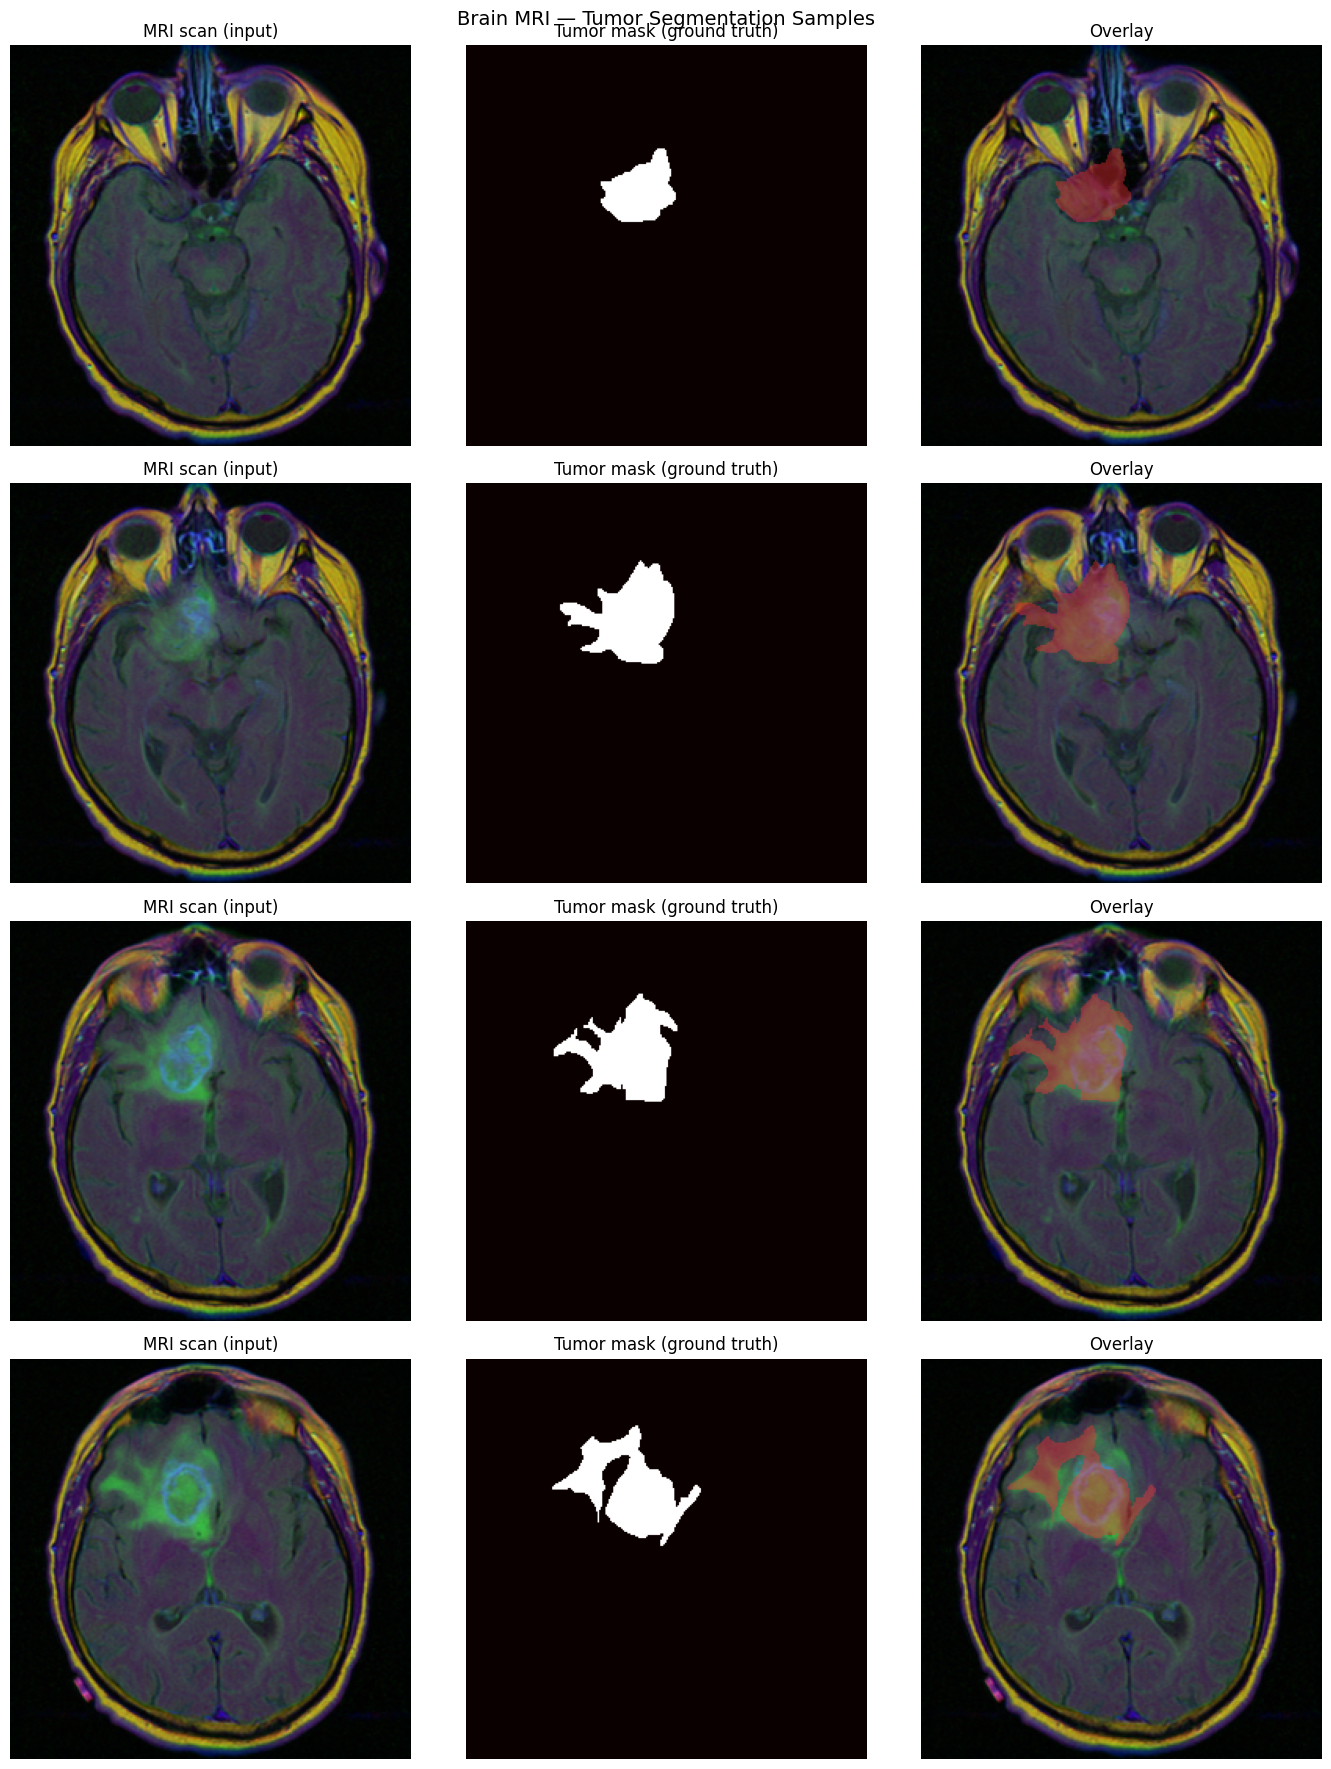

Saved: sample_visualization.png


In [7]:
# Find 4 samples that have a tumor
positive_samples = []
for img_p, msk_p in zip(image_paths, mask_paths):
    if len(positive_samples) >= 4:
        break
    m = np.array(Image.open(msk_p))
    if m.max() > 0:
        positive_samples.append((img_p, msk_p))

fig, axes = plt.subplots(4, 3, figsize=(14, 18))

for row, (ip, mp) in enumerate(positive_samples):
    img  = np.array(Image.open(ip).convert("RGB"))
    mask = np.array(Image.open(mp).convert("L"))

    overlay = img.copy()
    overlay[mask > 127] = [255, 50, 50]
    blended = (0.6 * img + 0.4 * overlay).astype(np.uint8)

    axes[row][0].imshow(img)
    axes[row][0].set_title("MRI scan (input)")
    axes[row][1].imshow(mask, cmap="hot")
    axes[row][1].set_title("Tumor mask (ground truth)")
    axes[row][2].imshow(blended)
    axes[row][2].set_title("Overlay")
    for ax in axes[row]:
        ax.axis("off")

plt.suptitle("Brain MRI — Tumor Segmentation Samples", fontsize=14)
plt.tight_layout()
plt.savefig("/content/sample_visualization.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: sample_visualization.png")

In [8]:
# Split at patient level to avoid data leakage
patient_dirs = sorted([
    d for d in os.listdir(base_path)
    if os.path.isdir(os.path.join(base_path, d))
])

print(f"Total patients: {len(patient_dirs)}")

train_patients, temp   = train_test_split(patient_dirs, test_size=0.2,  random_state=42)
val_patients,   test_patients = train_test_split(temp,  test_size=0.5,  random_state=42)

print(f"Train: {len(train_patients)} patients")
print(f"Val  : {len(val_patients)} patients")
print(f"Test : {len(test_patients)} patients")


def get_paths(patients):
    imgs, masks = [], []
    for p in patients:
        p_dir   = os.path.join(base_path, p)
        p_imgs  = sorted(glob.glob(os.path.join(p_dir, "*[!_mask].tif")))
        p_masks = sorted(glob.glob(os.path.join(p_dir, "*_mask.tif")))
        imgs.extend(p_imgs)
        masks.extend(p_masks)
    return imgs, masks

train_imgs, train_masks = get_paths(train_patients)
val_imgs,   val_masks   = get_paths(val_patients)
test_imgs,  test_masks  = get_paths(test_patients)

print(f"\nTrain images: {len(train_imgs)}")
print(f"Val images  : {len(val_imgs)}")
print(f"Test images : {len(test_imgs)}")

Total patients: 110
Train: 88 patients
Val  : 11 patients
Test : 11 patients

Train images: 3151
Val images  : 429
Test images : 349


In [9]:
class BrainMRIDataset(Dataset):
    def __init__(self, image_paths, mask_paths, transform=None):
        self.image_paths = image_paths
        self.mask_paths  = mask_paths
        self.transform   = transform

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img  = np.array(Image.open(self.image_paths[idx]).convert("RGB"))
        mask = np.array(Image.open(self.mask_paths[idx]).convert("L"))
        mask = (mask > 127).astype(np.float32)

        if self.transform:
            augmented = self.transform(image=img, mask=mask)
            img  = augmented["image"]
            mask = augmented["mask"].unsqueeze(0)

        return img, mask


train_transform = A.Compose([
    A.Resize(256, 256),
    A.HorizontalFlip(p=0.5),
    A.VerticalFlip(p=0.5),
    A.RandomRotate90(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.1, scale_limit=0.1, rotate_limit=15, p=0.4),
    A.RandomBrightnessContrast(p=0.4),
    A.GaussianBlur(blur_limit=3, p=0.2),
    A.ElasticTransform(p=0.2),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

val_test_transform = A.Compose([
    A.Resize(256, 256),
    A.Normalize(mean=(0.485, 0.456, 0.406), std=(0.229, 0.224, 0.225)),
    ToTensorV2(),
])

train_dataset = BrainMRIDataset(train_imgs, train_masks, transform=train_transform)
val_dataset   = BrainMRIDataset(val_imgs,   val_masks,   transform=val_test_transform)
test_dataset  = BrainMRIDataset(test_imgs,  test_masks,  transform=val_test_transform)

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True,  num_workers=2, pin_memory=True)
val_loader   = DataLoader(val_dataset,   batch_size=8,  shuffle=False, num_workers=2, pin_memory=True)
test_loader  = DataLoader(test_dataset,  batch_size=8,  shuffle=False, num_workers=2, pin_memory=True)

print(f"Train batches: {len(train_loader)}")
print(f"Val batches  : {len(val_loader)}")
print(f"Test batches : {len(test_loader)}")

Train batches: 197
Val batches  : 54
Test batches : 44


In [10]:
model = smp.Unet(
    encoder_name    = "resnet34",
    encoder_weights = "imagenet",
    in_channels     = 3,
    classes         = 1,
    activation      = None,
)
model = model.to(DEVICE)

# Sanity check
dummy = torch.randn(1, 3, 256, 256).to(DEVICE)
out   = model(dummy)
print(f"Input  shape: {dummy.shape}")
print(f"Output shape: {out.shape}")

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Trainable params: {total_params:,}")

config.json:   0%|          | 0.00/156 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/87.3M [00:00<?, ?B/s]

Input  shape: torch.Size([1, 3, 256, 256])
Output shape: torch.Size([1, 1, 256, 256])
Trainable params: 24,436,369


In [11]:
class DiceBCELoss(nn.Module):
    def __init__(self, smooth=1.0):
        super().__init__()
        self.smooth = smooth
        self.bce    = nn.BCEWithLogitsLoss()

    def forward(self, logits, targets):
        bce_loss  = self.bce(logits, targets)
        probs     = torch.sigmoid(logits)
        inter     = (probs * targets).sum(dim=(2, 3))
        dice_loss = 1 - (2 * inter + self.smooth) / \
                    (probs.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + self.smooth)
        return bce_loss + dice_loss.mean()


def dice_score(logits, targets, threshold=0.5, smooth=1.0):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    inter = (preds * targets).sum(dim=(2, 3))
    score = (2 * inter + smooth) / \
            (preds.sum(dim=(2,3)) + targets.sum(dim=(2,3)) + smooth)
    return score.mean().item()


def iou_score(logits, targets, threshold=0.5, smooth=1.0):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    inter = (preds * targets).sum(dim=(2, 3))
    union = preds.sum(dim=(2,3)) + targets.sum(dim=(2,3)) - inter
    return ((inter + smooth) / (union + smooth)).mean().item()


def precision_recall(logits, targets, threshold=0.5):
    probs = torch.sigmoid(logits)
    preds = (probs > threshold).float()
    tp = (preds * targets).sum().item()
    fp = (preds * (1 - targets)).sum().item()
    fn = ((1 - preds) * targets).sum().item()
    precision = tp / (tp + fp + 1e-8)
    recall    = tp / (tp + fn + 1e-8)
    return precision, recall

print("Loss and metrics defined.")

Loss and metrics defined.


In [12]:
import wandb
from tqdm import tqdm

wandb.init(
    project = "brain-mri-segmentation",
    config  = {
        "encoder"    : "resnet34",
        "pretrained" : "imagenet",
        "loss"       : "DiceBCE",
        "optimizer"  : "AdamW",
        "lr"         : 3e-4,
        "epochs"     : 60,
        "batch_size" : 16,
        "img_size"   : 256,
    }
)

criterion = DiceBCELoss()
optimizer = torch.optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=60, eta_min=1e-6)

EPOCHS    = 60
best_dice = 0.0
history   = {"train_loss": [], "val_dice": [], "val_iou": []}

for epoch in range(1, EPOCHS + 1):

    # ── Train ──
    model.train()
    running_loss = 0.0
    for imgs, masks in tqdm(train_loader, desc=f"Epoch {epoch:02d}/{EPOCHS} [Train]", leave=False):
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        optimizer.zero_grad()
        logits = model(imgs)
        loss   = criterion(logits, masks)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()
        running_loss += loss.item()

    avg_loss = running_loss / len(train_loader)

    # ── Validate ──
    model.eval()
    val_dices, val_ious = [], []
    with torch.no_grad():
        for imgs, masks in val_loader:
            imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
            logits = model(imgs)
            val_dices.append(dice_score(logits, masks))
            val_ious.append(iou_score(logits, masks))

    avg_dice = np.mean(val_dices)
    avg_iou  = np.mean(val_ious)
    scheduler.step()

    history["train_loss"].append(avg_loss)
    history["val_dice"].append(avg_dice)
    history["val_iou"].append(avg_iou)

    wandb.log({"train_loss": avg_loss, "val_dice": avg_dice,
               "val_iou": avg_iou, "epoch": epoch})

    print(f"Epoch {epoch:02d}/{EPOCHS} | Loss: {avg_loss:.4f} | Dice: {avg_dice:.4f} | IoU: {avg_iou:.4f}")

    if avg_dice > best_dice:
        best_dice = avg_dice
        torch.save(model.state_dict(), "/content/best_model.pth")
        print(f"  ✓ Best model saved (Dice: {best_dice:.4f})")

print(f"\nTraining complete. Best Val Dice: {best_dice:.4f}")
wandb.finish()

wandb: (1) Create a W&B account
wandb: (2) Use an existing W&B account
wandb: (3) Don't visualize my results
wandb: Enter your choice:

 2


wandb: You chose 'Use an existing W&B account'
wandb: Logging into https://api.wandb.ai. (Learn how to deploy a W&B server locally: https://wandb.me/wandb-server)
wandb: Create a new API key at: https://wandb.ai/authorize?ref=models
wandb: Store your API key securely and do not share it.
wandb: Paste your API key and hit enter:

 ··········


wandb: No netrc file found, creating one.
wandb: Appending key for api.wandb.ai to your netrc file: /root/.netrc
wandb: Currently logged in as: vedant2004 (vedant2004-savitribai-phule-pune-university) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


...

Epoch 57/60 | Loss: 0.2006 | Dice: 0.7726 | IoU: 0.7467


Epoch 58/60 | Loss: 0.2016 | Dice: 0.7753 | IoU: 0.7496


Epoch 59/60 | Loss: 0.2028 | Dice: 0.7760 | IoU: 0.7494


Epoch 60/60 | Loss: 0.2034 | Dice: 0.7710 | IoU: 0.7457

Training complete. Best Val Dice: 0.7940


epoch,▁▁▁▁▁▂▂▂▂▂▃▃▃▃▃▃▄▄▄▄▅▅▅▅▅▅▅▆▆▆▆▆▆▇▇▇▇▇██
train_loss,█▆▅▃▂▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁▁
val_dice,▁▅▅▆▅▆▆▇▇▇▆▆▇▆▇▆▇▇▇▇▇▇▆▇▇███▇▇▇▇▇▇▇▇▇▇█▇
val_iou,▅▁▅▆▅▇▆▆▇▆▇▇▇▇▇▇▇▇▇▇▇▇█▇▇▇███▇▇▇▇▇█████▇
epoch,60
train_loss,0.2034
val_dice,0.77097
val_iou,0.74573


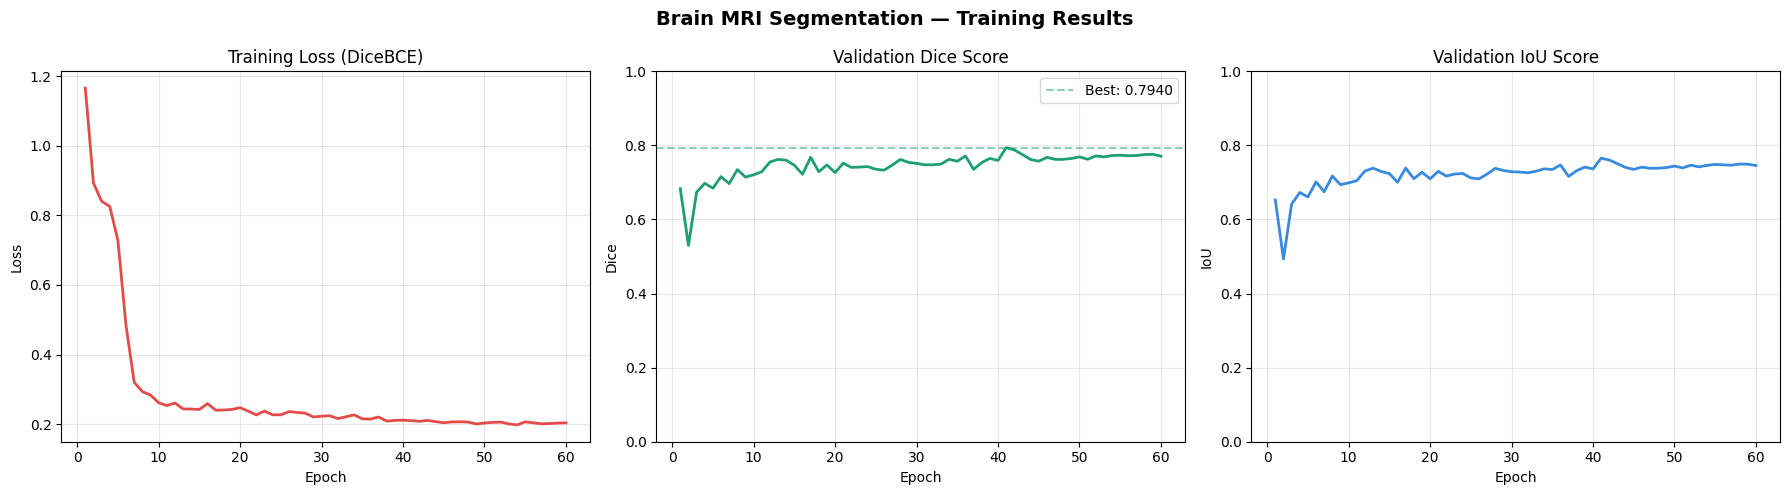

Saved: training_curves.png


In [13]:
epochs_range = range(1, len(history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle("Brain MRI Segmentation — Training Results", fontsize=14, fontweight="bold")

axes[0].plot(epochs_range, history["train_loss"], color="#E24B4A", linewidth=2)
axes[0].set_title("Training Loss (DiceBCE)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, history["val_dice"], color="#1D9E75", linewidth=2)
axes[1].axhline(y=best_dice, color="#1D9E75", linestyle="--", alpha=0.5,
                label=f"Best: {best_dice:.4f}")
axes[1].set_title("Validation Dice Score")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice")
axes[1].set_ylim(0, 1)
axes[1].legend()
axes[1].grid(alpha=0.3)

axes[2].plot(epochs_range, history["val_iou"], color="#378ADD", linewidth=2)
axes[2].set_title("Validation IoU Score")
axes[2].set_xlabel("Epoch")
axes[2].set_ylabel("IoU")
axes[2].set_ylim(0, 1)
axes[2].grid(alpha=0.3)

plt.tight_layout()
plt.savefig("/content/training_curves.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: training_curves.png")

In [14]:
model.load_state_dict(torch.load("/content/best_model.pth"))
model.eval()

test_dices, test_ious       = [], []
all_precisions, all_recalls = [], []

with torch.no_grad():
    for imgs, masks in test_loader:
        imgs, masks = imgs.to(DEVICE), masks.to(DEVICE)
        logits = model(imgs)
        test_dices.append(dice_score(logits, masks))
        test_ious.append(iou_score(logits, masks))
        p, r = precision_recall(logits, masks)
        all_precisions.append(p)
        all_recalls.append(r)

mean_dice = np.mean(test_dices)
mean_iou  = np.mean(test_ious)
mean_prec = np.mean(all_precisions)
mean_rec  = np.mean(all_recalls)
f1        = 2 * mean_prec * mean_rec / (mean_prec + mean_rec + 1e-8)

print("=" * 45)
print("        FINAL TEST SET RESULTS")
print("=" * 45)
print(f"  Dice Score : {mean_dice:.4f} ± {np.std(test_dices):.4f}")
print(f"  IoU Score  : {mean_iou:.4f} ± {np.std(test_ious):.4f}")
print(f"  Precision  : {mean_prec:.4f}")
print(f"  Recall     : {mean_rec:.4f}")
print(f"  F1 Score   : {f1:.4f}")
print("=" * 45)

        FINAL TEST SET RESULTS
  Dice Score : 0.7838 ± 0.1895
  IoU Score  : 0.7473 ± 0.2135
  Precision  : 0.3837
  Recall     : 0.4011
  F1 Score   : 0.3922


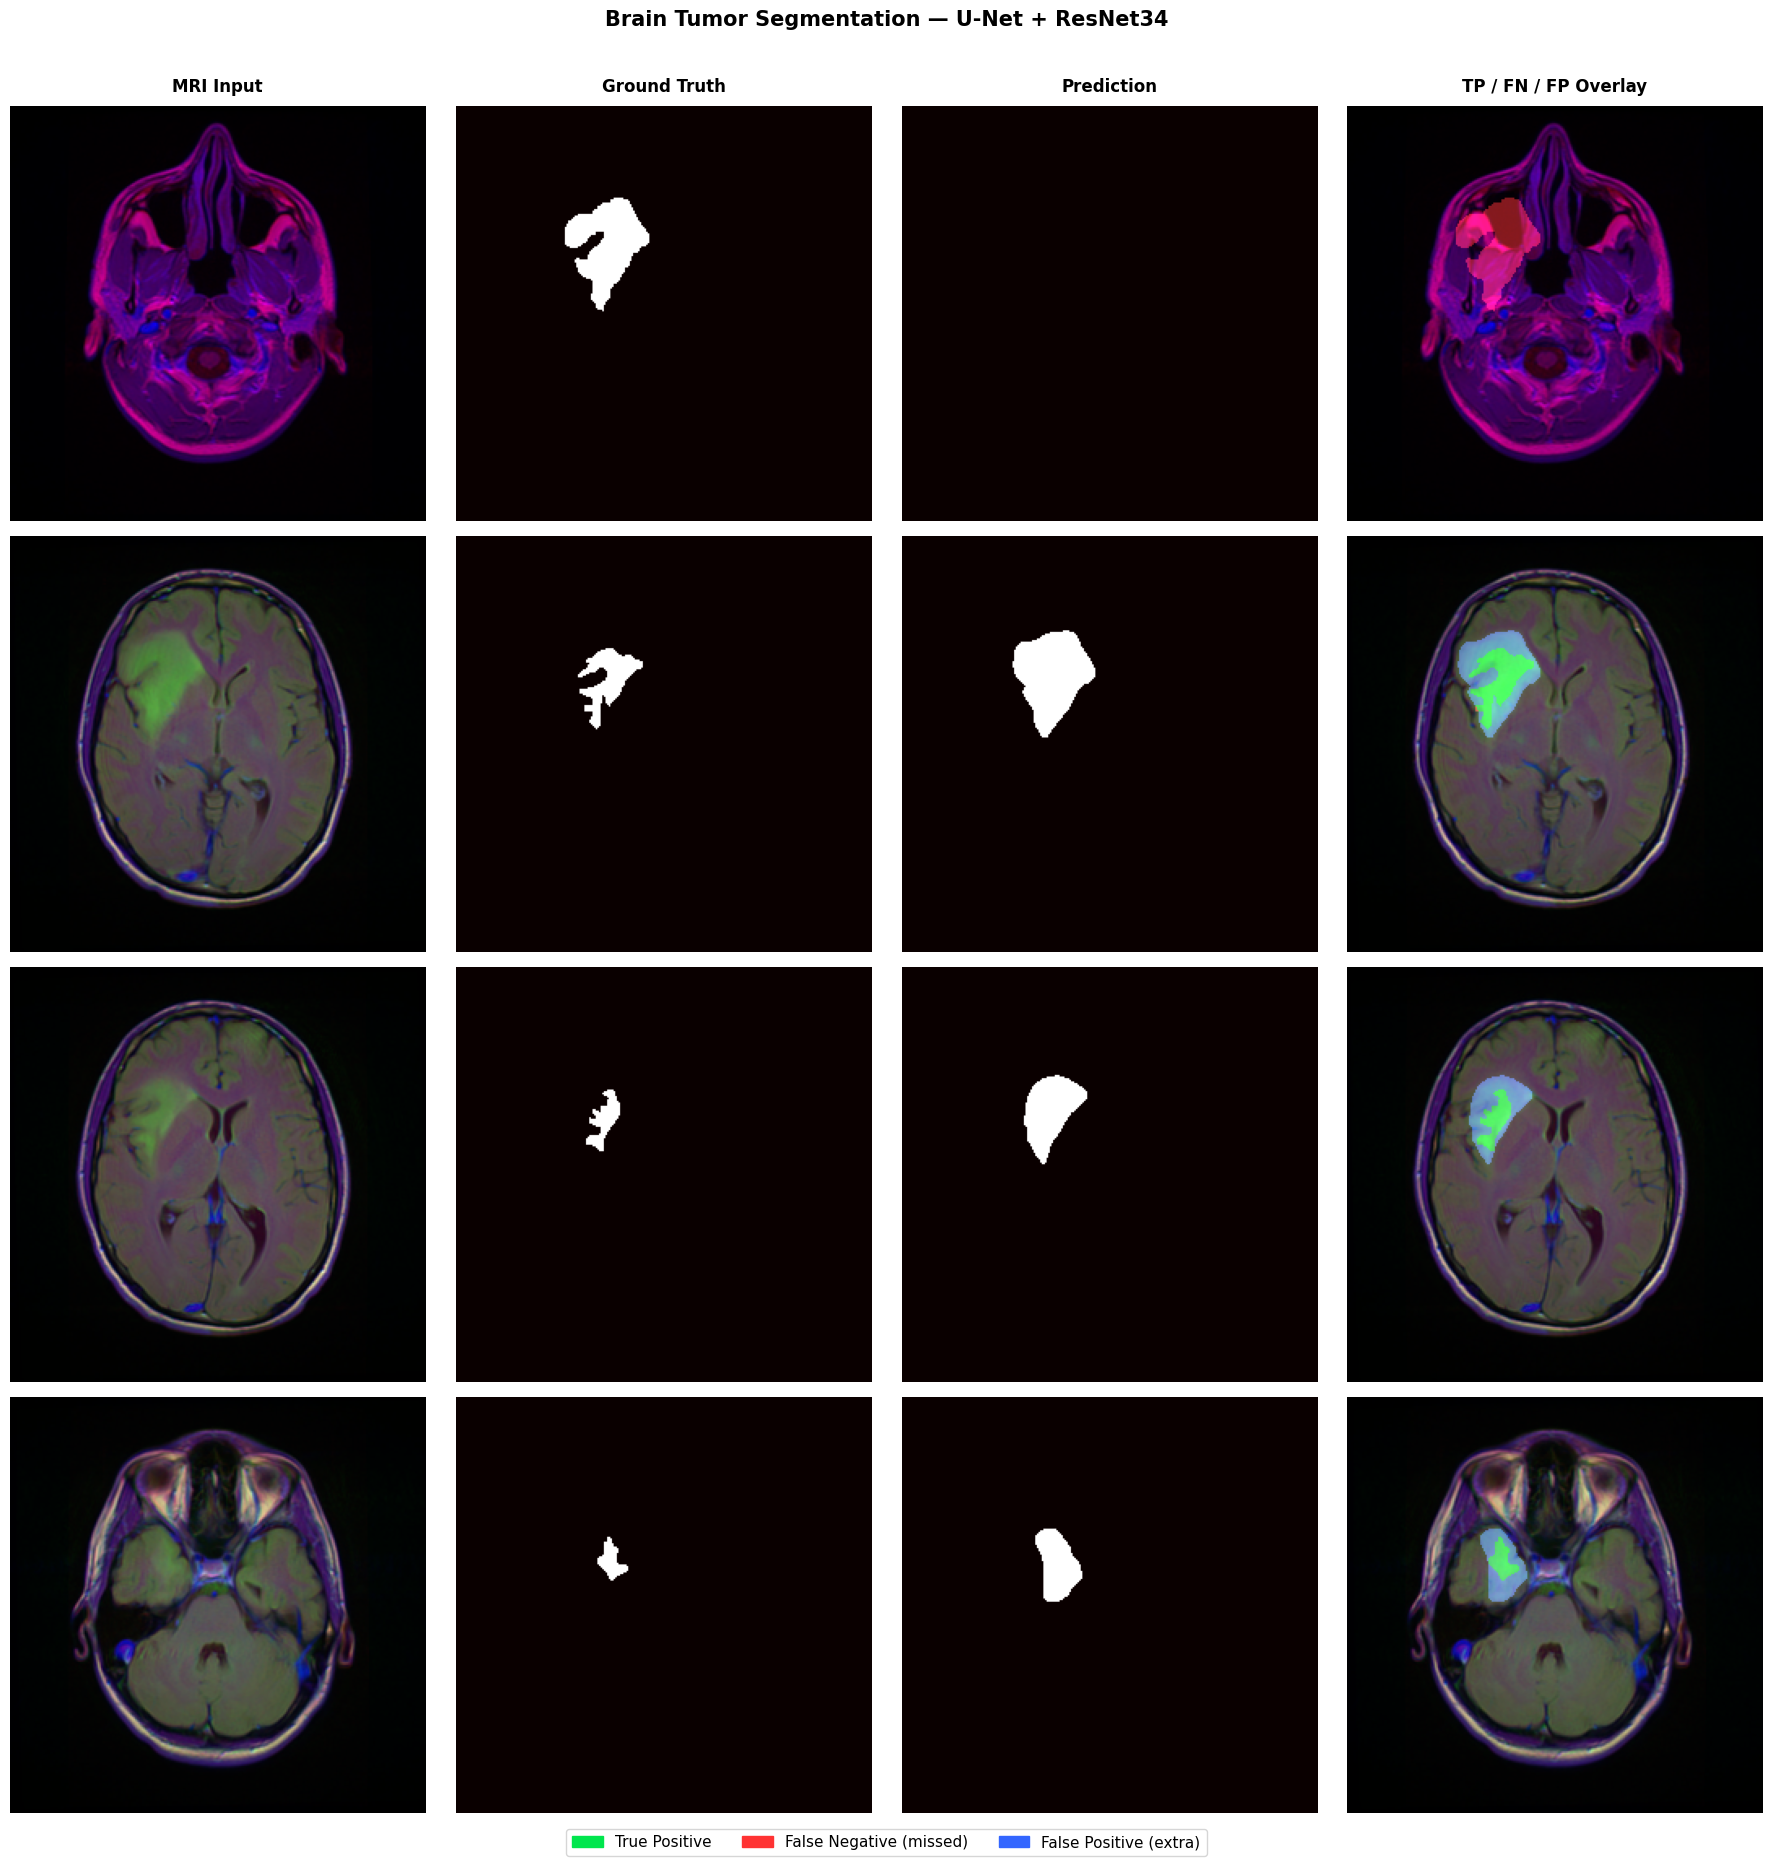

Saved: predictions.png


In [15]:
model.eval()

# Get 4 positive test samples
positive_test = [
    (ip, mp) for ip, mp in zip(test_imgs, test_masks)
    if np.array(Image.open(mp)).max() > 0
][:4]

MEAN = torch.tensor([0.485, 0.456, 0.406]).view(3,1,1).to(DEVICE)
STD  = torch.tensor([0.229, 0.224, 0.225]).view(3,1,1).to(DEVICE)

fig, axes = plt.subplots(4, 4, figsize=(18, 18))
fig.suptitle("Brain Tumor Segmentation — U-Net + ResNet34",
             fontsize=15, fontweight="bold", y=1.01)

col_titles = ["MRI Input", "Ground Truth", "Prediction", "TP / FN / FP Overlay"]
for col, title in enumerate(col_titles):
    axes[0][col].set_title(title, fontsize=12, fontweight="bold", pad=10)

with torch.no_grad():
    for row, (ip, mp) in enumerate(positive_test):
        img  = np.array(Image.open(ip).convert("RGB"))
        mask = (np.array(Image.open(mp).convert("L")) > 127).astype(np.float32)

        aug  = val_test_transform(image=img, mask=mask)
        inp  = aug["image"].unsqueeze(0).to(DEVICE)
        msk  = aug["mask"].numpy()

        logits = model(inp)
        prob   = torch.sigmoid(logits)[0, 0].cpu().numpy()
        pred   = (prob > 0.5).astype(np.float32)

        # Denormalize
        img_disp = (inp[0] * STD + MEAN).clamp(0,1).permute(1,2,0).cpu().numpy()

        # Colored error map
        overlay = np.zeros((*pred.shape, 3), dtype=np.float32)
        overlay[(pred==1) & (msk==1)] = [0.0, 0.9, 0.3]   # TP  green
        overlay[(pred==0) & (msk==1)] = [1.0, 0.2, 0.2]   # FN  red
        overlay[(pred==1) & (msk==0)] = [0.2, 0.4, 1.0]   # FP  blue
        blended = np.clip(img_disp + 0.5 * overlay, 0, 1)

        d = dice_score(logits,
                       torch.tensor(msk).unsqueeze(0).unsqueeze(0).to(DEVICE))

        axes[row][0].imshow(img_disp)
        axes[row][1].imshow(msk, cmap="hot")
        axes[row][2].imshow(pred, cmap="hot")
        axes[row][2].set_xlabel(f"Dice: {d:.3f}", fontsize=10)
        axes[row][3].imshow(blended)
        for ax in axes[row]: ax.axis("off")

patches = [
    mpatches.Patch(color=[0.0, 0.9, 0.3], label="True Positive"),
    mpatches.Patch(color=[1.0, 0.2, 0.2], label="False Negative (missed)"),
    mpatches.Patch(color=[0.2, 0.4, 1.0], label="False Positive (extra)"),
]
fig.legend(handles=patches, loc="lower center", ncol=3,
           fontsize=11, bbox_to_anchor=(0.5, -0.02))

plt.tight_layout()
plt.savefig("/content/predictions.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: predictions.png")

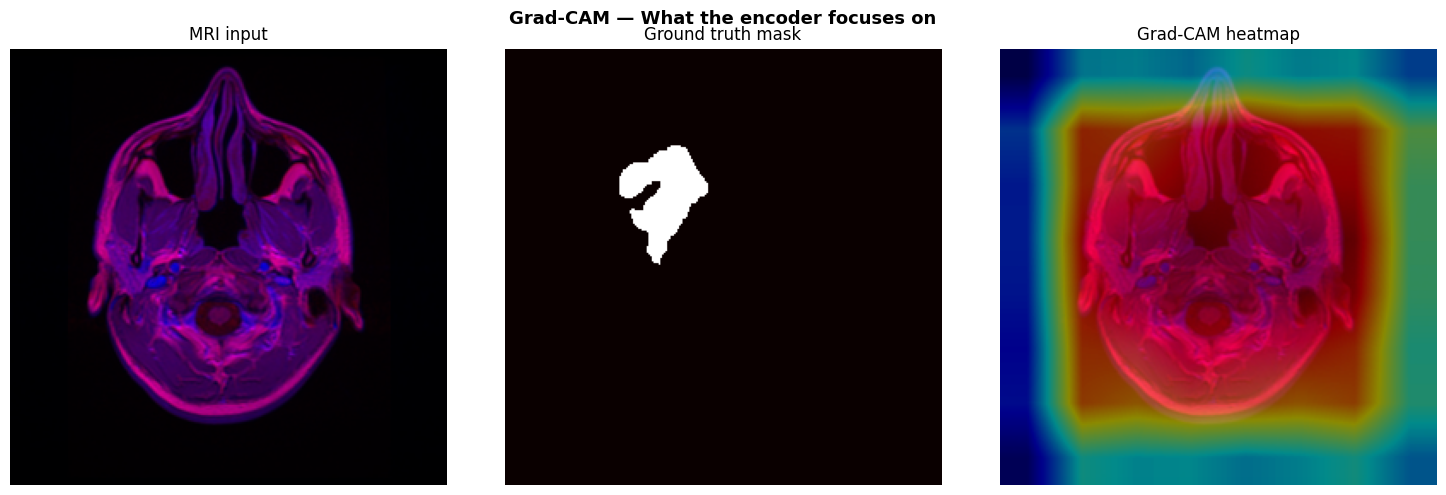

Saved: gradcam.png


In [17]:
from pytorch_grad_cam import GradCAM
from pytorch_grad_cam.utils.image import show_cam_on_image
import torch.nn.functional as F

# Fix: custom target for segmentation model
class SegmentationTarget:
    def __call__(self, model_output):
        # Reduce segmentation output to scalar by taking mean of sigmoid
        return torch.sigmoid(model_output).mean()

target_layers = [model.encoder.layer4[-1]]
cam = GradCAM(model=model, target_layers=target_layers)

ip, mp  = positive_test[0]
img     = np.array(Image.open(ip).convert("RGB"))
mask    = (np.array(Image.open(mp).convert("L")) > 127).astype(np.float32)

aug     = val_test_transform(image=img, mask=mask)
inp     = aug["image"].unsqueeze(0).to(DEVICE)

# Pass the custom target
targets = [SegmentationTarget()]
grayscale_cam = cam(input_tensor=inp, targets=targets)[0]

mean_np  = np.array([0.485, 0.456, 0.406])
std_np   = np.array([0.229, 0.224, 0.225])
img_disp = (aug["image"].permute(1,2,0).numpy() * std_np + mean_np).clip(0,1).astype(np.float32)
cam_img  = show_cam_on_image(img_disp, grayscale_cam, use_rgb=True)

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Grad-CAM — What the encoder focuses on", fontsize=13, fontweight="bold")
axes[0].imshow(img_disp);         axes[0].set_title("MRI input")
axes[1].imshow(mask, cmap="hot"); axes[1].set_title("Ground truth mask")
axes[2].imshow(cam_img);          axes[2].set_title("Grad-CAM heatmap")
for ax in axes: ax.axis("off")

plt.tight_layout()
plt.savefig("/content/gradcam.png", dpi=150, bbox_inches="tight")
plt.show()
print("Saved: gradcam.png")

In [18]:
from google.colab import files

output_files = [
    "/content/best_model.pth",
    "/content/sample_visualization.png",
    "/content/training_curves.png",
    "/content/predictions.png",
    "/content/gradcam.png",
]

for f in output_files:
    if os.path.exists(f):
        files.download(f)
        print(f"Downloaded: {f}")
    else:
        print(f"NOT FOUND: {f}")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: /content/best_model.pth


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

...

<IPython.core.display.Javascript object>

Downloaded: /content/predictions.png


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Downloaded: /content/gradcam.png
